There are 170 rows and 9 columns in our dataset.
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Recency (days)             int64
Frequency (visits)         int64
Monetary ($)               int64
Spending Score (1-100)     int64
Mail id                   object
dtype: object
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Recency (days)            0
Frequency (visits)        0
Monetary ($)              0
Spending Score (1-100)    0
Mail id                   0
dtype: int64
0

First 5 rows of the dataset:
   CustomerID  Gender  Age  Annual Income (k$)  Recency (days)  \
0           1    Male   19                  15              50   
1           2    Male   21                  15               5   
2           3  Female   20                  16              90   
3           4  Female   23                  16               5   
4           5

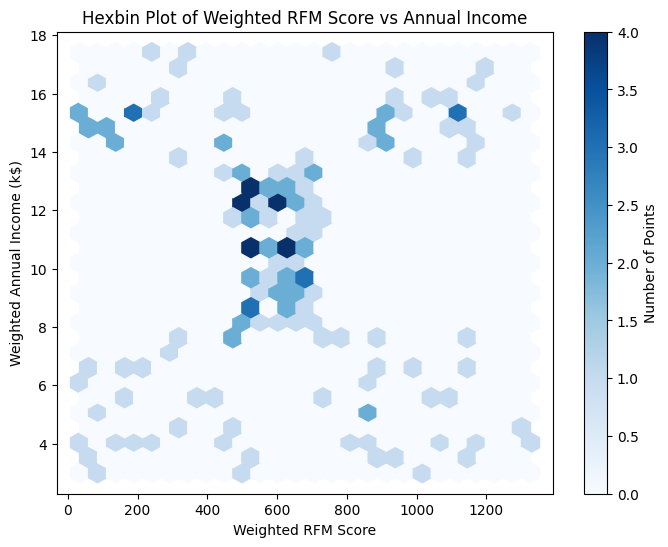

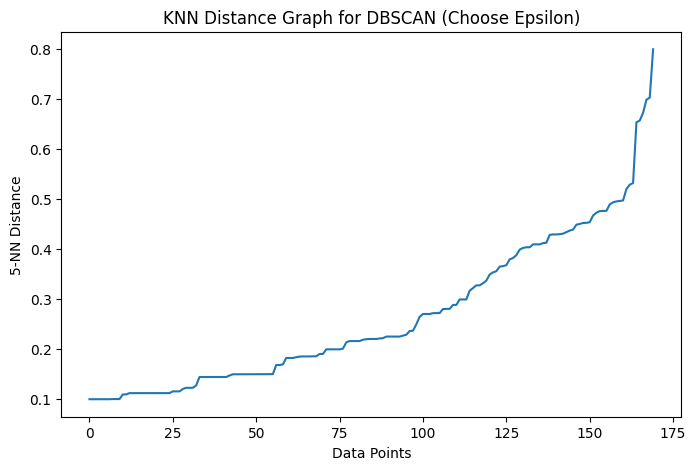


Estimated number of clusters: 6
Noise points: 6

Average RFM per Cluster:
                 Recency (days)  Frequency (visits)  Monetary ($)
DBSCAN Cluster                                                  
-1                        16.0                75.0        3017.0
 0                        85.0                 8.0         362.0
 1                        26.0                50.0        1878.0
 2                         4.0                84.0        3417.0
 3                        60.0                25.0        1314.0
 4                         5.0                81.0        3117.0
 5                        81.0                11.0         482.0


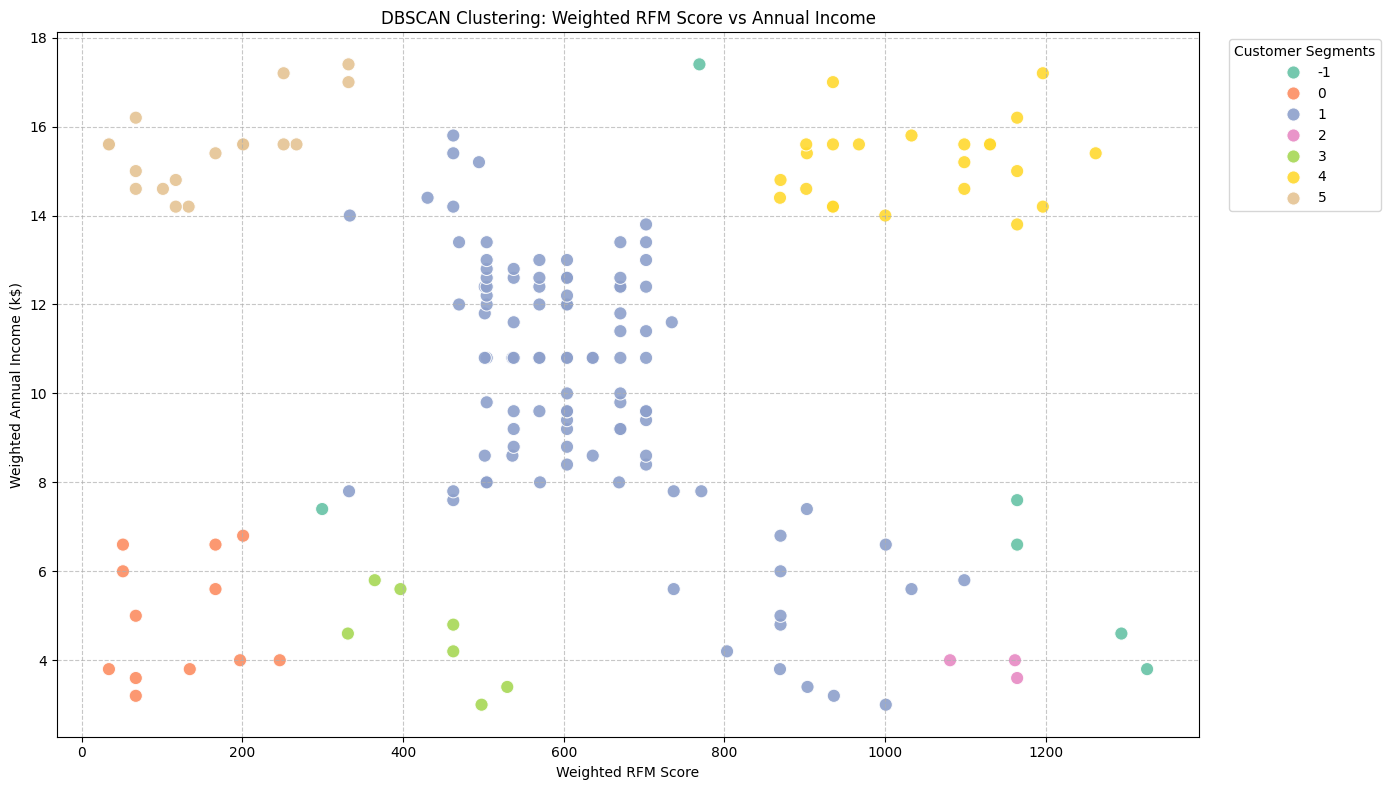


DBSCAN Model and Scaler saved in 'model_files/'


In [ ]:
import pandas as pd
import numpy as np
import pickle
import os
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Load dataset
df = pd.read_csv("customer_data.csv")

print(f'There are {df.shape[0]} rows and {df.shape[1]} columns in our dataset.')
print(df.dtypes)
print(df.isnull().sum())
print(df.duplicated().sum())
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Drop irrelevant columns
df.drop(columns=['CustomerID','Gender','Age','Spending Score (1-100)','Mail id'], inplace=True)

# Weights
WEIGHT_RECENCY = 0.2
WEIGHT_FREQUENCY = 0.4
WEIGHT_MONETARY = 0.4
WEIGHT_INCOME = 0.2
WEIGHT_RFM = 0.8

# Composite RFM
df['RFM Score'] = (
    WEIGHT_RECENCY * (100 - df['Recency (days)']) +
    WEIGHT_FREQUENCY * df['Frequency (visits)'] +
    WEIGHT_MONETARY * df['Monetary ($)']
)

# Weighted dataset
x_rfm_income = df[['RFM Score','Annual Income (k$)']].copy()

x_rfm_income['RFM Score'] *= WEIGHT_RFM
x_rfm_income['Annual Income (k$)'] *= WEIGHT_INCOME

# Add components
x_rfm_income[['Recency (days)','Frequency (visits)','Monetary ($)']] = \
df[['Recency (days)','Frequency (visits)','Monetary ($)']]

# Hexbin visualization
plt.figure(figsize=(8,6))
plt.hexbin(x_rfm_income['RFM Score'],x_rfm_income['Annual Income (k$)'],
           gridsize=25,cmap='Blues')
plt.colorbar(label='Number of Points')
plt.xlabel('Weighted RFM Score')
plt.ylabel('Weighted Annual Income (k$)')
plt.title('Hexbin Plot of Weighted RFM Score vs Annual Income')
plt.show()

# Standardization
scaler = StandardScaler()
x_scaled = scaler.fit_transform(
    x_rfm_income[['RFM Score','Annual Income (k$)']]
)

# -------- KNN distance plot for epsilon --------
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(x_scaled)
distances, indices = neighbors_fit.kneighbors(x_scaled)

distances = np.sort(distances[:,4], axis=0)

plt.figure(figsize=(8,5))
plt.plot(distances)
plt.title("KNN Distance Graph for DBSCAN (Choose Epsilon)")
plt.xlabel("Data Points")
plt.ylabel("5-NN Distance")
plt.show()

# DBSCAN parameters
eps = 0.45
min_samples = 5

db = DBSCAN(eps=eps, min_samples=min_samples)
labels = db.fit_predict(x_scaled)

x_rfm_income['DBSCAN Cluster'] = labels

# Cluster count
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("\nEstimated clusters:", n_clusters)

noise_points = list(labels).count(-1)
print("Noise points:", noise_points)

# ---------- Evaluation Metrics ----------
mask = labels != -1

if len(set(labels[mask])) > 1:
    sil_score = silhouette_score(x_scaled[mask], labels[mask])
    db_score = davies_bouldin_score(x_scaled[mask], labels[mask])

    print("\nSilhouette Score:", round(sil_score,3))
    print("Davies-Bouldin Index:", round(db_score,3))

# ---------- Calculate pseudo-centroids ----------
centroids = x_rfm_income[x_rfm_income['DBSCAN Cluster']!=-1] \
            .groupby('DBSCAN Cluster')[['RFM Score','Annual Income (k$)']] \
            .mean()

print("\nCluster Centroids:")
print(centroids)

# ---------- Average RFM ----------
cluster_rfm_means = x_rfm_income.groupby('DBSCAN Cluster')[[
'Recency (days)','Frequency (visits)','Monetary ($)'
]].mean().round(0)

print("\nAverage RFM per Cluster:\n",cluster_rfm_means)

# ---------- Visualization ----------
plt.figure(figsize=(14,8))

sns.scatterplot(
    data=x_rfm_income,
    x='RFM Score',
    y='Annual Income (k$)',
    hue='DBSCAN Cluster',
    palette='Set2',
    s=90,
    edgecolor='white',
    alpha=0.9
)

# Plot centroids
for cluster_id,(rfm,income) in centroids.iterrows():
    plt.scatter(rfm,income,
                c='black',
                s=300,
                marker='X',
                edgecolor='white',
                linewidth=1.5)

    plt.text(rfm+0.2,income,
             str(cluster_id),
             fontsize=12,
             weight='bold')

plt.title('DBSCAN Clustering: Weighted RFM Score vs Annual Income')
plt.xlabel('Weighted RFM Score')
plt.ylabel('Weighted Annual Income (k$)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.legend(title='Customer Segments',
           bbox_to_anchor=(1.02,1),
           loc='upper left')

plt.tight_layout()
plt.show()

# ---------- Save model ----------
os.makedirs("model_files", exist_ok=True)

with open("model_files/dbscan_model.pkl","wb") as f:
    pickle.dump(db,f)

with open("model_files/scaler.pkl","wb") as f:
    pickle.dump(scaler,f)

print("\nDBSCAN Model and Scaler saved in 'model_files/'")